In [1]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

Done


In [12]:
sample['CG4_Gals'].columns

Index(['objid', 'specobjid', 'Group', 'RA', 'Dec', 'M_r', 'Lum', 'z',
       'dist2BGG', 'lgm', 'sfr', 'sSFR', 'rank_dist', 'rank_M', 'RA_BGG',
       'Dec_BGG', 'M_BGG', 'sSFR_status', 'p_E', 'p_S', 'is_dominated',
       'morphology', 'sSFR_raw', 'sSFR_MS_offset', 'MS_res', 'sSFR_excess'],
      dtype='object')

In [9]:
sample.keys()

dict_keys(['CG4_Gals', 'Control4B_Gals', 'Control4C_Gals', 'RG4_Gals', 'CG4_Groups', 'Control4B_Groups', 'Control4C_Groups', 'RG4_Groups', 'SDSS'])

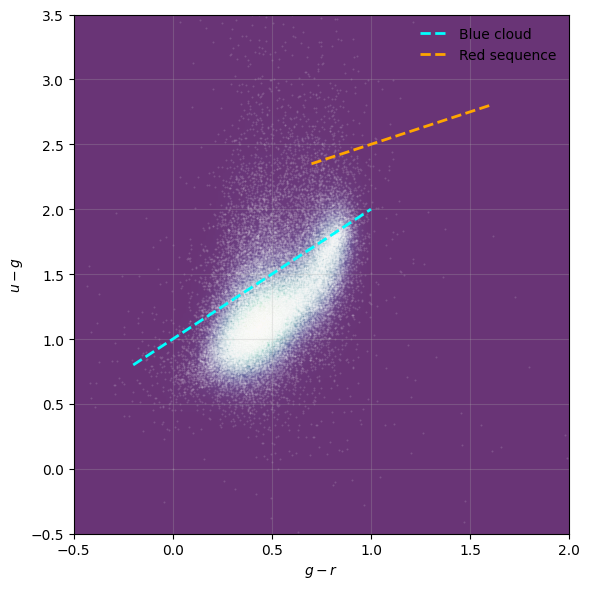

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

sdss = sample["SDSS"]

# --- Colors ---
x = sdss["petroMag_g"] - sdss["r_obs"]   # g − r
y = sdss["petroMag_u"] - sdss["petroMag_g"]   # u − g

# Remove NaNs / inf
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# --- KDE ---
values = np.vstack([x, y])
kde = gaussian_kde(values)

xmin, xmax = -0.5, 2.0
ymin, ymax = -0.5, 3.5

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid).reshape(xx.shape)

# --- Plot ---
plt.figure(figsize=(6, 6))

# Density map
plt.imshow(
    np.rot90(zz),
    extent=[xmin, xmax, ymin, ymax],
    cmap="viridis",
    aspect="auto",
    alpha=0.8
)

# Scatter (light overlay)
plt.scatter(x, y, s=2, c="white", alpha=0.15, linewidths=0)

# -------------------------------------------------
# ⭐ STANDARD OVERLAYS
# -------------------------------------------------

# # Stellar locus (approx.)
# g_r_locus = np.linspace(-0.4, 1.6, 200)
# u_g_locus = (
#     1.2 + 1.8*g_r_locus
#     - 0.8*g_r_locus**2
#     + 0.15*g_r_locus**3
# )

# plt.plot(
#     g_r_locus,
#     u_g_locus,
#     color="red",
#     linewidth=2,
#     label="Stellar locus (approx.)"
# )

# Blue cloud guide
g_r_blue = np.linspace(-0.2, 1.0, 200)
u_g_blue = 1.0 + 1.0*g_r_blue

plt.plot(
    g_r_blue,
    u_g_blue,
    linestyle="--",
    color="cyan",
    linewidth=2,
    label="Blue cloud"
)

# Red sequence guide
g_r_red = np.linspace(0.7, 1.6, 200)
u_g_red = 2.0 + 0.5*g_r_red

plt.plot(
    g_r_red,
    u_g_red,
    linestyle="--",
    color="orange",
    linewidth=2,
    label="Red sequence"
)

# -------------------------------------------------

plt.xlabel(r"$g-r$")
plt.ylabel(r"$u-g$")

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend(frameon=False)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


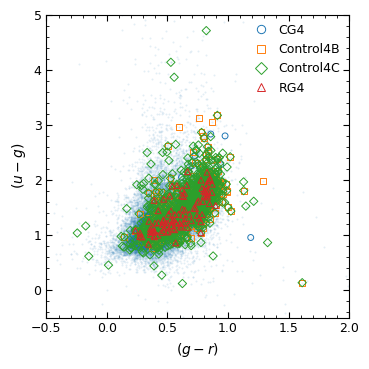

CG4_Gals: matched 110 galaxies
Control4B_Gals: matched 931 galaxies
Control4C_Gals: matched 1478 galaxies
RG4_Gals: matched 102 galaxies


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

# -----------------------------
# Helpers
# -----------------------------
def _as_int(series):
    """Robust cast for ID matching (handles uint64/int/strings with NaNs)."""
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def match_subsample_to_sdss(sample, subsample_key, sdss_key="SDSS"):
    """
    Returns a merged DF for a given subsample, adding petroMag_u/g/i/z from SDSS
    by matching specobjid (subsample) to specObjID (SDSS).
    """
    df_sub = sample[subsample_key].copy()
    df_sdss = sample[sdss_key].copy()

    # Normalize join keys
    df_sub["_specid"]  = _as_int(df_sub["specobjid"])
    df_sdss["_specid"] = _as_int(df_sdss["specObjID"])

    # Keep only the SDSS columns we need
    cols_sdss = ["_specid", "petroMag_u", "petroMag_g", "r_obs", "petroMag_i", "petroMag_z"]
    df_sdss_small = df_sdss[cols_sdss].drop_duplicates("_specid")

    merged = df_sub.merge(df_sdss_small, on="_specid", how="inner")
    return merged

# -----------------------------
# Build colour-colour for SDSS background
# -----------------------------
df_sdss = sample["SDSS"].copy()

# Ensure numeric
for c in ["petroMag_u", "petroMag_g", "r_obs"]:
    df_sdss[c] = pd.to_numeric(df_sdss[c], errors="coerce")

df_sdss["u_g"] = df_sdss["petroMag_u"] - df_sdss["petroMag_g"]
df_sdss["g_r"] = df_sdss["petroMag_g"] - df_sdss["r_obs"]

# Clean: finite only
mask_sdss = np.isfinite(df_sdss["u_g"]) & np.isfinite(df_sdss["g_r"])
df_sdss_cc = df_sdss.loc[mask_sdss, ["u_g", "g_r"]]

# -----------------------------
# Match subsamples and compute colours
# -----------------------------
sub_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
sub_dfs = {}

for k in sub_keys:
    m = match_subsample_to_sdss(sample, k)

    # Ensure numeric
    m["petroMag_u"] = pd.to_numeric(m["petroMag_u"], errors="coerce")
    m["petroMag_g"] = pd.to_numeric(m["petroMag_g"], errors="coerce")
    m["r_obs"]      = pd.to_numeric(m["r_obs"], errors="coerce")

    # Colours
    m["u_g"] = m["petroMag_u"] - m["petroMag_g"]
    m["g_r"] = m["petroMag_g"] - m["r_obs"]

    m = m[np.isfinite(m["u_g"]) & np.isfinite(m["g_r"])]
    sub_dfs[k] = m

# -----------------------------
# A&A-style figure settings
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

fig, ax = plt.subplots(figsize=(3.54, 3.54))  # ~A&A single-column width

# SDSS background: rasterized to keep vector PDF small
ax.scatter(
    df_sdss_cc["g_r"], df_sdss_cc["u_g"],
    s=2, alpha=0.12, linewidths=0,
    rasterized=True, label="SDSS"
)

# -----------------------------
# Overlays: explicit colours + markers
# -----------------------------
markers = {
    "CG4_Gals": "o",
    "Control4B_Gals": "s",
    "Control4C_Gals": "D",
    "RG4_Gals": "^",
}

colors = {
    "CG4_Gals": "C0",
    "Control4B_Gals": "C1",
    "Control4C_Gals": "C2",
    "RG4_Gals": "C3",
}

for k in sub_keys:
    dfk = sub_dfs[k]
    ax.scatter(
        dfk["g_r"], dfk["u_g"],
        s=18,
        marker=markers[k],
        linewidths=0.7,
        facecolors="none",
        edgecolors=colors[k],
    )

# -----------------------------
# Labels, limits, ticks
# -----------------------------
ax.set_xlabel(r"$(g - r)$")   # petroMag_g - r_obs
ax.set_ylabel(r"$(u - g)$")   # petroMag_u - petroMag_g

# limit x and y to focus on main locus
ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 5.0)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which="both", top=True, right=True)

# -----------------------------
# Legend with proxy artists (guarantees correct open-marker rendering)
# -----------------------------
legend_handles = [
    Line2D([0], [0], marker=markers["CG4_Gals"],       color=colors["CG4_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="CG4"),
    Line2D([0], [0], marker=markers["Control4B_Gals"], color=colors["Control4B_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="Control4B"),
    Line2D([0], [0], marker=markers["Control4C_Gals"], color=colors["Control4C_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="Control4C"),
    Line2D([0], [0], marker=markers["RG4_Gals"],       color=colors["RG4_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="RG4"),
]

ax.legend(handles=legend_handles, frameon=False, loc="best", handletextpad=0.4, borderaxespad=0.3)

fig.tight_layout(pad=0.2)

# Save in publication-friendly formats
# fig.savefig("ug_gr_AA.pdf", dpi=300)
# fig.savefig("ug_gr_AA.png", dpi=300)

plt.show()

# Quick sanity prints (how many matched points)
for k in sub_keys:
    print(f"{k}: matched {len(sub_dfs[k])} galaxies")

In [16]:
for cat in ['CG4_Gals', 'Control4B_Gals', 'Control4C_Gals', 'RG4_Gals']:
    print(f"{cat}: {len(sample[cat])} galaxies, matched {len(sub_dfs[cat])} with SDSS photometry")

CG4_Gals: 248 galaxies, matched 110 with SDSS photometry
Control4B_Gals: 2792 galaxies, matched 931 with SDSS photometry
Control4C_Gals: 3004 galaxies, matched 1478 with SDSS photometry
RG4_Gals: 224 galaxies, matched 102 with SDSS photometry
